In [1]:
from model_environment import BeachMap, sim_properties

In [2]:
bm = BeachMap()

In [3]:
sim_properties

{'boardwalk': {'color': 'sienna'},
 'beach': {'color': 'sandybrown'},
 'shallow': {'color': 'lightblue'},
 'open_water': {'color': 'steelblue'},
 'person_to_rescue': {'color': 'red', 'as_bool': True, 'alpha': 0.5},
 'base': {'color': 'black'}}

(10, 10)

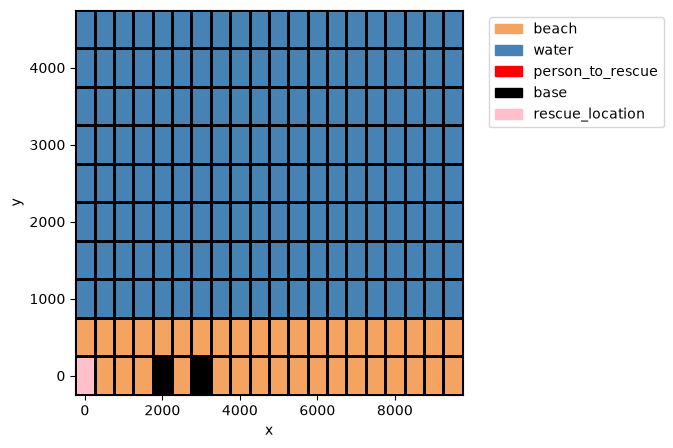

In [3]:

bm.show(properties=sim_properties)
bm.check_vicinity((10,10))

In [4]:
from model_environment import BeachMap, BeachEnvironment, sim_properties
from uas import RescueDrone
import fmdtools.sim.propagate as prop

be = BeachEnvironment()
drone = RescueDrone(beachenvironment=be)

result, hist = prop.nominal(drone)

history length: 2


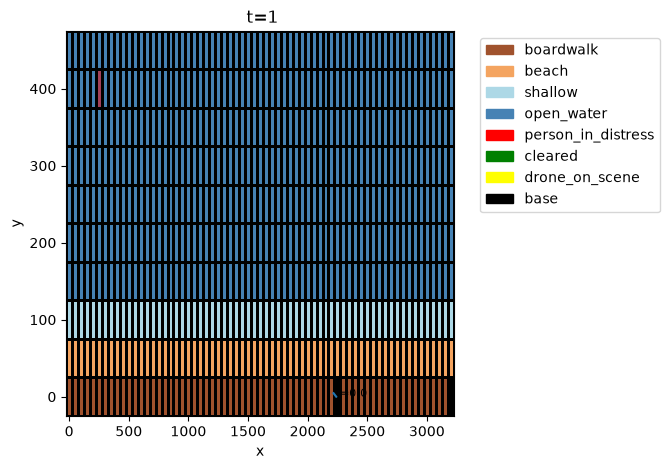

In [5]:
be = BeachEnvironment()
drone = RescueDrone(beachenvironment=be, track="all",
                    sp={'end_time': 1, 'dt': 1.0})

result, hist = prop.nominal(drone, protect=False)

actual_len = len(hist.beachenvironment.c.person_in_distress)
print("history length:", actual_len)

fig, ax = drone.beachenvironment.c.show_from(
    actual_len - 1, hist.beachenvironment.c, properties=sim_properties
)
hist.plot_trajectory('s.x', 's.y', fig=fig, ax=ax, mark_time=True, time_ticks=200.0)

In [6]:
from fmdtools.sim import propagate
from model_environment import DistressPropagation
fp = DistressPropagation(track='all', beachenvironment=BeachEnvironment())
res, hist = propagate.nominal(fp, protect=False)

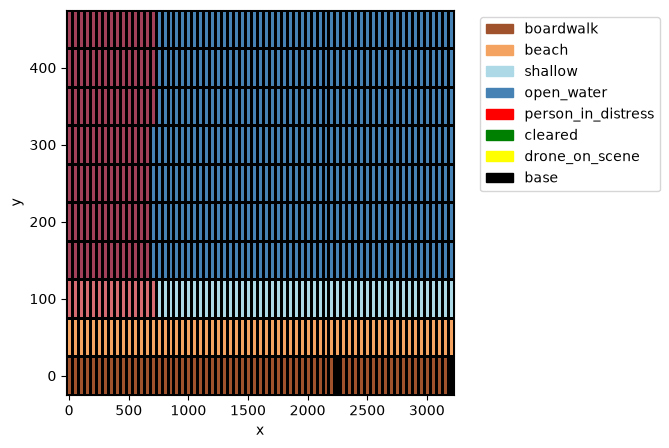

In [7]:
fig, ax = fp.beachenvironment.c.show(properties=sim_properties)

In [8]:
fe = BeachEnvironment()
fe.prop_time()
a1 = RescueDrone()


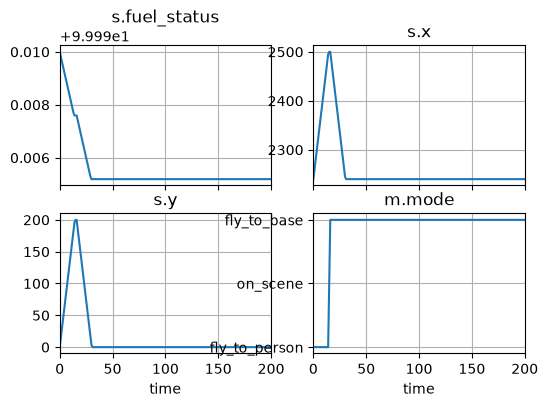

In [9]:
from model_environment import BeachEnvironment
from uas import RescueDrone
from fmdtools.sim import propagate

# num_distress=0 -> no auto-targeting, so the drone honors the goal we set below
be = BeachEnvironment(c={"p": {"base_locations": ((2240.0, 0.0),), "num_distress": 3}})
be.prop_time()

# the target is whatever we set it to be:
a1 = RescueDrone(s={'goal_x': 1500, 'goal_y': 300}, beachenvironment=be, track="all",
                 sp={'end_time': 200, 'dt': 1.0})

res, hist = propagate.nominal(a1, protect=False)
fig, ax = hist.plot_line('s.fuel_status', 's.x', 's.y', 'm.mode')